In [1]:
from ref import *
from read_complex_matrix import read_complex_matrix
matr = read_complex_matrix('ref_matrix.txt')
import timeit

In [2]:
%%time

x_crit, x_max, y_max, x_min, y_min = reflectometry_trace(matr[1,2], matr[1,0], matr[2,2], matr[2,0])

CPU times: user 3.75 ms, sys: 0 ns, total: 3.75 ms
Wall time: 3.21 ms


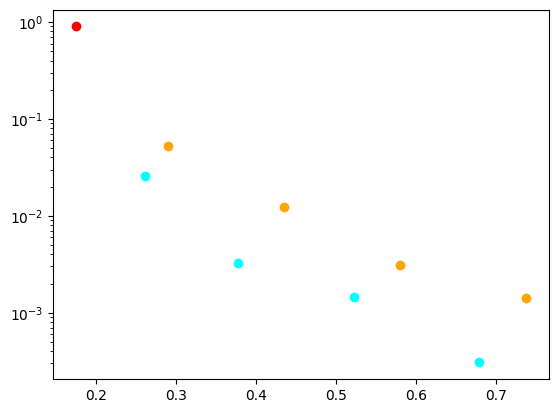

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

#ax.plot(q[0:len(r_conv)]*1e-9, r_conv)
ax.scatter(x_max*1e-9, y_max, color = 'orange')
ax.scatter(x_min*1e-9, y_min, color = 'cyan')
ax.scatter(x_crit*1e-9, 0.9, color = 'red')

ax.set_yscale('log')

plt.show()

In [4]:
def loss_function(crit1, r_max1, q_max1, r_min1, q_min1, crit2, r_max2, q_max2, r_min2, q_min2):
    #r_min могут плохо сходиться в случаях со свёрткой, т.к. она их завышает на порядок
    return (2*(crit1-crit2)/crit1)**2 + np.sum(((r_max1-r_max2)/r_max1)**2) + np.sum(((q_max1-q_max2)/q_max1)**2) + np.sum(((q_min1-q_min2)/q_min1)**2)

In [5]:
def objective_function(params):
    rough1, len1, rough2, len2 = params
    crit1, r_max1, q_max1, r_min1, q_min1 = reflectometry_trace(matr[1,2], matr[1,0], matr[2,2], matr[2,0])
    crit2, r_max2, q_max2, r_min2, q_min2 = reflectometry_trace(rough1, len1, rough2, len2)
    return loss_function(crit1, r_max1, q_max1, r_min1, q_min1, crit2, r_max2, q_max2, r_min2, q_min2)

In [6]:
from scipy.optimize import differential_evolution as de

# диапазон для шероховатостей и глубин (для двух поверхностных слоёв)
bounds = [[0, 8e-9], [3.e-08, 5.e-08],
          [0, 8e-9], [1.4e-8, 2.6e-8]]

In [9]:
%%time

result = de(
    func=objective_function,
    bounds=bounds,
    workers=24  # Параллельные вычисления
)

CPU times: user 5.25 s, sys: 1.5 s, total: 6.76 s
Wall time: 15.9 s


In [10]:
print("Optimal parameters:")
for ans in result.x:
    print(f"param = {ans}")
print(f"Minimum objective value = {result.fun}")

Optimal parameters:
param = 3.99999999999987e-09
param = 3.9999999999999835e-08
param = 2.000000000000237e-09
param = 2.0000000000000156e-08
Minimum objective value = 2.10023804562768e-29



    Работает? Да. 
    Главный трабл - размерности "следов" могут отличаться при поиске => прога крашится.
    Костыль: ограничить количество экстремумов наперёд заданным числом, уменьшить интервал величин.

    Также довольно существенно увеличивается время работы при увеличении числа параметров.
    